In [1]:
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

from matplotlib import colormaps

colors = ["#E69F00", "#56B4E9", "#009E73", "#D55E00", "#0072B2"]

from astropy.coordinates import SkyCoord, EarthLocation, solar_system_ephemeris, get_body_barycentric, get_body, AltAz
from astropy.time import Time, TimeDelta
from astropy import units as u

from datetime import datetime
import glob
import os
from pathlib import Path
import json
import re

import requests

from io import BytesIO

mid = np.array([4788, 3194]) # Middle of the image.

In [2]:
import sys
sys.path.append("~/repos/desioops/py")

In [3]:
from desioops.coordinates import altaz_to_xy
from desioops.util import filename_to_time, filename_to_time_str
from desioops.coordinates import find_object_com

In [4]:
# KPNO location
loc = EarthLocation.of_site('kpno')

# Arizona (MST) is UTC-7 year-round, no daylight saving
utc_offset = 7 * u.hour  # local midnight ≈ 07:00 UTC

# We will search +- 2 days of every new moon to try ensure there is no light
# contamination from the moon.
new_moons = ["2026-01-18", "2026-02-17", "2026-03-18", "2026-04-17", "2026-05-16", "2026-06-14", "2026-07-14", "2026-08-12", "2026-09-10", "2026-10-10", "2026-11-08", "2026-12-08"]
new_moons = Time(new_moons, scale="utc")
search_days = (new_moons[:, None] + np.arange(-2, 2) * u.day).flatten()
print(search_days)

# Window around local midnight sampled every 2.5 min, 
# which is about half of the update cadence of the camera.
# But we don't process images multiple times.
window = np.arange(-3, 3, 1/24) * u.hour
times = (search_days[:, None] + utc_offset + window).flatten()

altaz_frame = AltAz(obstime=times, location=loc)
jupiter = get_body('jupiter', times, loc)
jaa = jupiter.transform_to(altaz_frame)

['2026-01-16 00:00:00.000' '2026-01-17 00:00:00.000'
 '2026-01-18 00:00:00.000' '2026-01-19 00:00:00.000'
 '2026-02-15 00:00:00.000' '2026-02-16 00:00:00.000'
 '2026-02-17 00:00:00.000' '2026-02-18 00:00:00.000'
 '2026-03-16 00:00:00.000' '2026-03-17 00:00:00.000'
 '2026-03-18 00:00:00.000' '2026-03-19 00:00:00.000'
 '2026-04-15 00:00:00.000' '2026-04-16 00:00:00.000'
 '2026-04-17 00:00:00.000' '2026-04-18 00:00:00.000'
 '2026-05-14 00:00:00.000' '2026-05-15 00:00:00.000'
 '2026-05-16 00:00:00.000' '2026-05-17 00:00:00.000'
 '2026-06-12 00:00:00.000' '2026-06-13 00:00:00.000'
 '2026-06-14 00:00:00.000' '2026-06-15 00:00:00.000'
 '2026-07-12 00:00:00.000' '2026-07-13 00:00:00.000'
 '2026-07-14 00:00:00.000' '2026-07-15 00:00:00.000'
 '2026-08-10 00:00:00.000' '2026-08-11 00:00:00.000'
 '2026-08-12 00:00:00.000' '2026-08-13 00:00:00.000'
 '2026-09-08 00:00:00.000' '2026-09-09 00:00:00.000'
 '2026-09-10 00:00:00.000' '2026-09-11 00:00:00.000'
 '2026-10-08 00:00:00.000' '2026-10-09 00:00:0

In [5]:
# We need jupiter to be visible. A couple degrees above the horizon would be great.
good_jup = jaa.alt > (5 * u.deg)
# Can't get images from beyond today. Ignore things before the utc change over, it's causing me a headache.
good_time = (times < Time(datetime.today())) & (times > Time("2026-02-25", scale="utc"))
jaa = jaa[good_jup & good_time]
times = times[good_jup & good_time]
len(jaa)

1099

In [6]:
def time_to_fname(time):
    # Before this date files are saved in local time not UTC.
    if time < Time("2026-02-16T12:49:36.000"):
        t = str(time - TimeDelta(7 * u.hour))
    else:
        t = str(time)
    replace = ["-", ":", " ", "T"]
    for r in replace:
        t = t.replace(r, "")
    t = t[:-4]

    return t

In [7]:
time_names = [time_to_fname(t) for t in times]
all_days = np.array([t[:8] for t in time_names], dtype=int)
time_names = np.array(time_names, dtype=int)
unique_days = np.unique(all_days)

In [8]:
# We capture only the date because it makes it more directly
# comparable to our test time strings which don't include the .jpg
# (for finding the image taken closest up to that time)
r = re.compile(r'HREF="(\d{14}).jpg"')
def get_all_images_for_date(date):
    resp = requests.get(f"http://kpasca-archives.tuc.noirlab.edu/{date}/index.html")
    return r.findall(resp.text)

In [9]:
with open("best_fit.json", "r") as f:
    fit_params = json.load(f)

In [10]:
import json
# Helper function that will write each fit to the json file saving all fits.
def write_to_file(x_final, y_final, date, obj):
    out_loc = "fit_locs.json"
    bak_loc = "fit_locs_bak.json"
    if Path(out_loc).exists():
        with open(out_loc, "r") as f:
            data = json.load(f)
        with open(bak_loc, "w") as f:
            f.writelines(json.dumps(data))
    else:
        data = {}

    if date in data.keys():
        data[date].append([x_final, y_final, obj])
    else:
        data[date] = [[x_final, y_final, obj]]

    with open(out_loc, "w") as f:
        f.writelines(json.dumps(data))

In [11]:
curr_date = unique_days[0]
ims = np.array(get_all_images_for_date(curr_date), dtype=int)

# Loop over all individual 5 minute times
# on this day, taking the latest image before
# that time (if it exists and was not already processed)
done_ims = []
taken_today = all_days == curr_date

for t in time_names[taken_today]:
    idx = np.argmax(ims > t) - 1

    curr_time = ims[idx]
    print(f"Current timestamp {t}, found image {curr_time}")
    if curr_time not in done_ims:
        print("Image not processed, processing now...")
        resp = requests.get(f"http://kpasca-archives.tuc.noirlab.edu/{curr_date}/{ims[idx]}.jpg")
        im = np.asarray(Image.open(BytesIO(resp.content)))

        # Using the best fit parameters and the alt az from astropy,
        # find the estimated x, y on the image.
        time = filename_to_time(str(curr_time))
        aa_ref = AltAz(location=loc, obstime=time)
        
        jupiter = get_body('jupiter', time, loc)
        j_im = jupiter.transform_to(aa_ref)
        
        x, y = altaz_to_xy(j_im.alt.degree, j_im.az.degree, "equisolid", fit_params["equisolid"], np.rad2deg(fit_params["theta"]))

        # Using that estimated x, y, make a box around it as a patch and find the
        # actual location of jupiter on the image. It should be the brightest thing,
        # but just in case there are more objects bright enough to threshold the
        # image there the first pass of this algorithm does a weighted average of 
        # all bright objects. Jupiter should be the biggest.

        # Need x and y as integer coordinate positions for
        # slicing the image. Just cast to an integer,
        # we will always be within half a pixel of the position this way.
        x_p = int(x + mid[0])
        y_p = int(y + mid[1])
        
        x_found, y_found = find_object_com(im, x_p, y_p, 500, 50)

        # Save based on the exact timestamp we actually used to get the estimate position (for later)
        save_time = time_to_fname(time)
        write_to_file(x_found, y_found, save_time, "jupiter")

        done_ims.append(curr_time)
        

Current timestamp 20260316040000, found image 20260316035958
Image not processed, processing now...
Current timestamp 20260316040230, found image 20260316035958
Current timestamp 20260316040500, found image 20260316040440
Image not processed, processing now...
Current timestamp 20260316040730, found image 20260316040440
Current timestamp 20260316041000, found image 20260316040944
Image not processed, processing now...
Current timestamp 20260316041230, found image 20260316040944
Current timestamp 20260316041500, found image 20260316041402
Image not processed, processing now...
Current timestamp 20260316041730, found image 20260316041402
Current timestamp 20260316042000, found image 20260316041946
Image not processed, processing now...
Current timestamp 20260316042230, found image 20260316041946
Current timestamp 20260316042500, found image 20260316042402
Image not processed, processing now...
Current timestamp 20260316042730, found image 20260316042402
Current timestamp 20260316043000, 

In [12]:
out_loc = "fit_locs.json"

with open(out_loc, "r") as f:
   data = json.load(f)

In [13]:
dates = list(data.keys())

all_times = []
all_x = []
all_y = []
for date in dates:
    xs, ys, objs = zip(*data[date])

    if "jupiter" not in objs: continue
    idx = objs.index("jupiter")
    all_x.append(xs[idx])
    all_y.append(ys[idx])
    all_times.append(filename_to_time_str(date, noshift=True))

    
all_x = np.array(all_x) - mid[0]
all_y = np.array(all_y) - mid[1]
all_times = Time(all_times, scale="utc")

In [14]:
all_times

<Time object: scale='utc' format='isot' value=['2026-03-13T03:09:17.000' '2026-06-22T04:04:35.000'
 '2026-03-18T09:29:43.000' '2026-02-20T03:04:39.000'
 '2026-01-15T09:04:54.000' '2026-03-16T03:59:58.000'
 '2026-03-16T04:04:40.000' '2026-03-16T04:09:44.000'
 '2026-03-16T04:14:02.000' '2026-03-16T04:19:46.000'
 '2026-03-16T04:24:02.000' '2026-03-16T04:29:01.000'
 '2026-03-16T04:34:04.000' '2026-03-16T04:39:59.000'
 '2026-03-16T04:44:02.000' '2026-03-16T04:49:01.000'
 '2026-03-16T04:53:59.000' '2026-03-16T04:59:09.000'
 '2026-03-16T05:04:21.000' '2026-03-16T05:09:22.000'
 '2026-03-16T05:14:25.000' '2026-03-16T05:19:31.000'
 '2026-03-16T05:24:07.000' '2026-03-16T05:29:26.000'
 '2026-03-16T05:34:12.000' '2026-03-16T05:39:33.000'
 '2026-03-16T05:44:05.000' '2026-03-16T05:49:15.000'
 '2026-03-16T05:54:27.000' '2026-03-16T05:59:35.000'
 '2026-03-16T06:04:36.000' '2026-03-16T06:09:36.000'
 '2026-03-16T06:14:43.000' '2026-03-16T06:19:36.000'
 '2026-03-16T06:24:33.000' '2026-03-16T06:29:37.000'


In [15]:
r_pred = np.hypot(all_x, all_y)
phi_pred = np.atan2(all_x, all_y)
phi_pred = phi_pred + np.pi

aa_ref = AltAz(location=loc, obstime=all_times)
bodies = get_body("jupiter", all_times, loc).transform_to(aa_ref)

theta_true = np.deg2rad(90 - bodies.alt.degree)
phi_true = np.deg2rad(bodies.az.degree)

In [16]:
proj = {"equidistant": lambda x: x, "orthographic": lambda x: np.sin(x), "stereographic": lambda x: 2 * np.tan(x / 2), "equisolid": lambda x: 2 * np.sin(x / 2) }
reverse_proj = {"equidistant": lambda x: x, "orthographic": lambda x: np.arcsin(x), "stereographic": lambda x: 2 * np.arctan(x / 2), "equisolid": lambda x: 2 * np.arcsin(x / 2) }

equidistant best fit scale 2214.9222779027696, R2=0.9949, image radius 3479.19
orthographic best fit scale 2794.657917783436, R2=0.9462, image radius 2794.66
stereographic best fit scale 1932.0068819725284, R2=0.9486, image radius 3864.01
equisolid best fit scale 2349.374239420094, R2=0.9996, image radius 3322.52


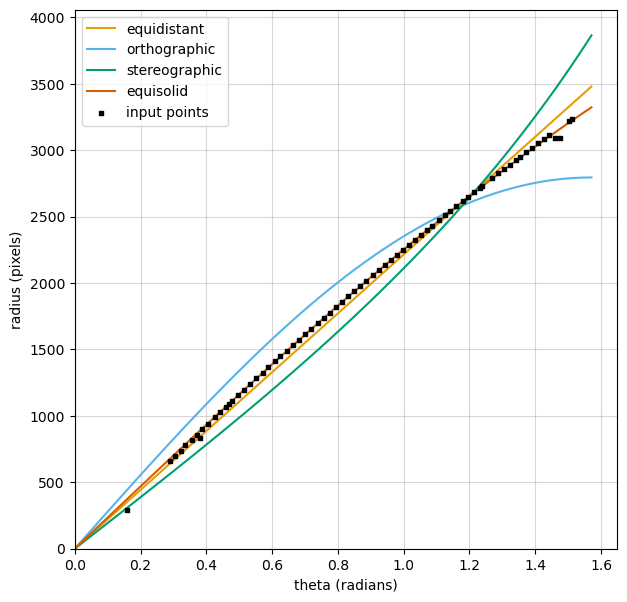

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))

fits = {}
y_true = r_pred
theta_points = np.linspace(0, np.pi / 2, 60)
for i, (label, f) in enumerate(proj.items()):
    y_pred = f(theta_true)
    a = np.sum(y_true * y_pred) / np.sum(y_pred ** 2)
    y_pred = a * y_pred
    R2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    # plt.plot(all_thetas, y_pred,  "-o", label=label)
    fits[label] = a
    y_points = a * f(theta_points)
    print(f"{label} best fit scale {a}, {R2=:.4f}, image radius {y_points[-1]:.2f}")
    plt.plot(theta_points, y_points, label=label, c=colors[i])

plt.scatter(theta_true, r_pred, s=8, marker="s", label="input points", zorder=10, c="k")

ax.legend()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.set(ylabel="radius (pixels)", xlabel="theta (radians)", xlim=(0, xlim[-1]), ylim=(0, ylim[-1]))
ax.grid(alpha=0.5)

best fit offset b=0.2045 radians, 11.7180 degrees


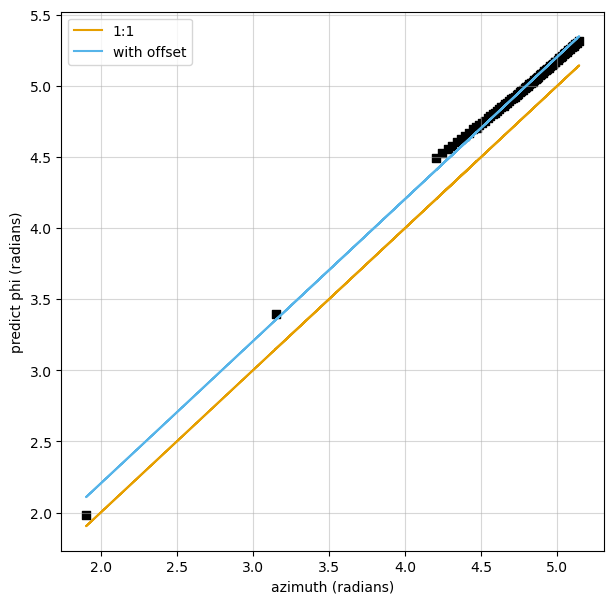

In [18]:
fig, ax = plt.subplots(figsize=(7, 7))

plt.scatter(phi_true, phi_pred, c="k", marker="s")
plt.plot(phi_true, phi_true, c=colors[0], label="1:1")

b = np.mean(phi_pred - phi_true)
print(f"best fit offset {b=:.4f} radians, {np.rad2deg(b):.4f} degrees")
plt.plot(phi_true, phi_true + b, c=colors[1], label="with offset")

ax.grid(alpha=0.5)
ax.set(xlabel="azimuth (radians)", ylabel="predict phi (radians)")
ax.legend()

In [19]:
len(phi_pred)

72

[(-3325.0, 3325.0), (3325.0, -3325.0)]

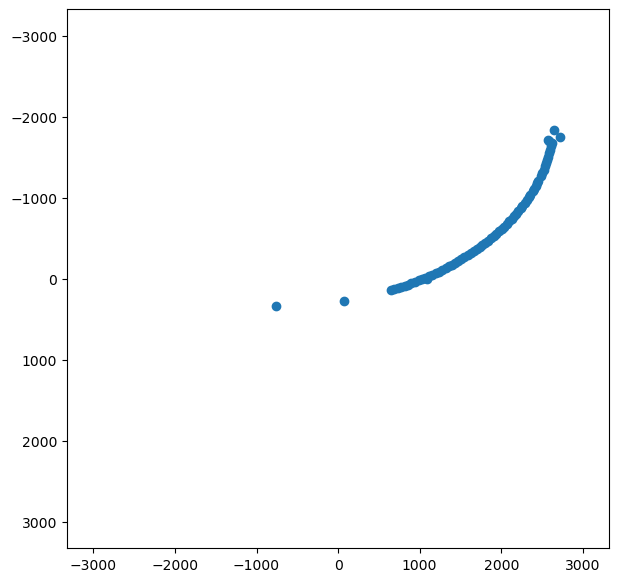

In [26]:
fig, ax = plt.subplots(figsize=(7, 7))
plt.scatter(all_x, all_y)
# ax.invert_yaxis()
im_rad = 3325
ax.set(xlim=(-im_rad, im_rad), ylim=(im_rad, -im_rad))